In [1]:
import pandas as pd, glob

# Load one station, one product
files = glob.glob("../noaa_data_pipeline/data/coops/station=*/**/**/*.parquet", recursive=True)
df = pd.concat([pd.read_parquet(f) for f in sorted(files)])

print(df.shape)
print(df.isnull().sum())
print(df.describe())
df.head(30)

(64829253, 8)
timestamp              0
station_id             0
product                0
value           10537533
quality_flag    42536808
speed           37174089
dr              58131906
direction       59275800
dtype: int64
                           timestamp         value         speed     direction
count                       64829253  5.429172e+07  2.765516e+07  5.553453e+06
mean   2012-10-10 17:43:36.217700608  1.971984e+02  7.995371e-01  1.621911e+02
min              1996-01-01 00:00:00 -1.790000e+01 -9.999000e+01  0.000000e+00
25%              2005-10-11 06:18:00  1.084000e+00  9.000000e-03  4.600000e+01
50%              2013-05-22 17:36:00  5.300000e+00  1.700000e-02  1.770000e+02
75%              2019-08-15 19:30:00  2.270000e+01  6.800000e-02  2.540000e+02
max              2026-03-04 23:54:00  1.045700e+03  2.280000e+01  9.999000e+03
std                              NaN  3.948667e+02  1.966652e+00  1.335705e+02


,timestamp,station_id,product,value,quality_flag,speed,dr,direction
0,1998-10-01 00:00:00,8516945,air_pressure,NaN,NaN,NaN,NaN,NaN
1,1998-10-01 00:06:00,8516945,air_pressure,NaN,NaN,NaN,NaN,NaN
2,1998-10-01 00:12:00,8516945,air_pressure,NaN,NaN,NaN,NaN,NaN
3,1998-10-01 00:18:00,8516945,air_pressure,NaN,NaN,NaN,NaN,NaN
4,1998-10-01 00:24:00,8516945,air_pressure,NaN,NaN,NaN,NaN,NaN
5,1998-10-01 00:30:00,8516945,air_pressure,NaN,NaN,NaN,NaN,NaN
6,1998-10-01 00:36:00,8516945,air_pressure,NaN,NaN,NaN,NaN,NaN
7,1998-10-01 00:42:00,8516945,air_pressure,NaN,NaN,NaN,NaN,NaN
8,1998-10-01 00:48:00,8516945,air_pressure,NaN,NaN,NaN,NaN,NaN
9,1998-10-01 00:54:00,8516945,air_pressure,NaN,NaN,NaN,NaN,NaN


In [2]:
df_wide = df.pivot_table(index="timestamp", columns="product", values="value", aggfunc="first")
df_wide.columns.name = None
df_wide = df_wide.reset_index()
df_wide.head(30)


,timestamp,air_pressure,air_temperature,water_level,water_temperature
0,1998-10-30 13:00:00,1011.1,9.5,NaN,14.6
1,1998-10-30 13:06:00,NaN,9.8,NaN,14.6
2,1998-10-30 13:10:00,1011.1,NaN,NaN,NaN
3,1998-10-30 13:12:00,NaN,9.7,NaN,14.6
4,1998-10-30 13:18:00,NaN,9.7,NaN,14.5
5,1998-10-30 13:24:00,NaN,9.8,NaN,14.7
6,1998-10-30 13:30:00,NaN,9.9,NaN,14.5
7,1998-10-30 13:36:00,NaN,10.0,NaN,14.5
8,1998-10-30 13:40:00,800.0,NaN,NaN,NaN
9,1998-10-30 13:42:00,NaN,9.9,NaN,14.6


In [3]:
df_by_hour = df_wide[df_wide["timestamp"].dt.minute == 0]
df_by_hour.head(100)


,timestamp,air_pressure,air_temperature,water_level,water_temperature
0,1998-10-30 13:00:00,1011.1,9.5,NaN,14.6
12,1998-10-30 14:00:00,1010.4,10.3,NaN,14.5
22,1998-10-30 15:00:00,1009.6,11.1,NaN,14.2
32,1998-10-30 16:00:00,1008.9,11.9,NaN,14.1
44,1998-10-30 17:00:00,1007.3,12.6,NaN,14.3
...,...,...,...,...,...
1010,1998-11-03 12:00:00,NaN,NaN,1.387,NaN
1020,1998-11-03 13:00:00,1015.0,6.9,2.214,13.0
1032,1998-11-03 14:00:00,1013.9,7.3,2.535,13.0
1042,1998-11-03 15:00:00,1014.0,7.8,2.573,12.8


In [4]:
df_by_hour.isnull().sum()

timestamp                0
air_pressure          6449
air_temperature      17422
water_level             35
water_temperature    40668
dtype: int64

In [5]:
df_by_hour.describe()

,timestamp,air_pressure,air_temperature,water_level,water_temperature
count,239509,233060.000000,222087.000000,239474.000000,198841.000000
mean,2012-07-02 04:55:41.170477824,1016.640867,12.349133,1.258761,12.832319
min,1998-10-30 13:00:00,965.700000,-17.600000,-1.177000,-7.300000
25%,2005-08-31 05:00:00,1011.700000,5.000000,0.433000,5.500000
50%,2012-06-30 02:00:00,1016.600000,12.400000,1.257000,12.800000
75%,2019-05-06 02:00:00,1021.700000,20.400000,2.080000,20.100000
max,2026-03-04 23:00:00,1045.400000,37.100000,4.361000,44.700000
std,NaN,7.898539,9.247054,0.876564,7.821328


In [6]:
df.tail(100)

,timestamp,station_id,product,value,quality_flag,speed,dr,direction
860,2026-03-04 14:00:00,8516945,wind,NaN,NaN,1.1,NE,34.0
861,2026-03-04 14:06:00,8516945,wind,NaN,NaN,2.2,NNE,24.0
862,2026-03-04 14:12:00,8516945,wind,NaN,NaN,1.9,NNE,28.0
863,2026-03-04 14:18:00,8516945,wind,NaN,NaN,1.8,NNE,32.0
864,2026-03-04 14:24:00,8516945,wind,NaN,NaN,1.6,NNE,32.0
...,...,...,...,...,...,...,...,...
955,2026-03-04 23:30:00,8516945,wind,NaN,NaN,3.3,SSE,168.0
956,2026-03-04 23:36:00,8516945,wind,NaN,NaN,3.5,SSE,160.0
957,2026-03-04 23:42:00,8516945,wind,NaN,NaN,3.8,SSE,164.0
958,2026-03-04 23:48:00,8516945,wind,NaN,NaN,3.9,SSE,164.0


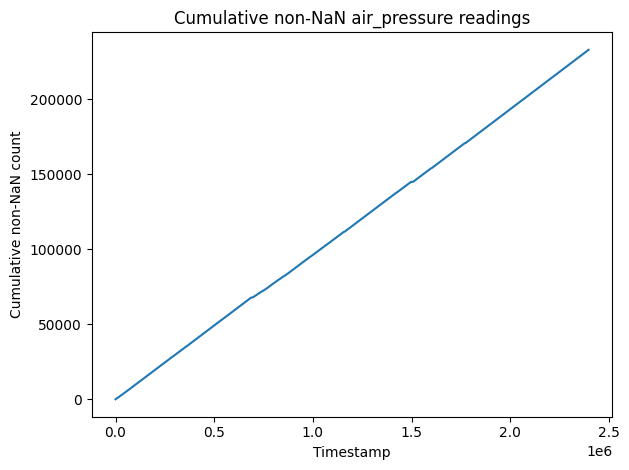

In [7]:
import matplotlib.pyplot as plt

ax = df_by_hour["air_pressure"].notna().cumsum().plot(title="Cumulative non-NaN air_pressure readings")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Cumulative non-NaN count")
plt.tight_layout()
plt.show()


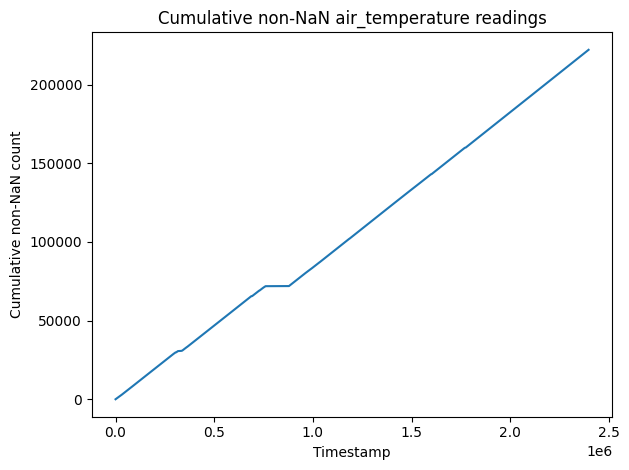

In [8]:
ax = df_by_hour["air_temperature"].notna().cumsum().plot(title="Cumulative non-NaN air_temperature readings")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Cumulative non-NaN count")
plt.tight_layout()
plt.show()


In [9]:
df_by_hour.iloc[[120000]]

,timestamp,air_pressure,air_temperature,water_level,water_temperature
1201898,2012-07-10 08:00:00,1014.5,22.1,2.19,22.2


In [10]:
df_by_hour.iloc[[121631]]

,timestamp,air_pressure,air_temperature,water_level,water_temperature
1218208,2012-09-16 07:00:00,1018.5,17.8,1.123,22.5


In [11]:
df_by_hour.reset_index(drop=True, inplace=True)

In [12]:
print(df_by_hour["air_pressure"].first_valid_index())
print(df_by_hour["air_temperature"].first_valid_index())

0
0
